In [1]:
import numpy as np
import torch
from flow_matching import *
from dit import *

# --------------------------------------
# Load mel spec
# --------------------------------------
npz_path = "data/mel_specs/001.clar.npz"     # <-- change this
data = np.load(npz_path)
mel = data["mel"]                  # shape: (n_mels=128, T)

# Use exactly first 128 frames
mel = mel[:, :128]                 # (128, 128)


# --------------------------------------
# Prepare model input (B, L, D)
# --------------------------------------
mel = torch.from_numpy(mel).float()         # (128, 128)
mel = mel.unsqueeze(0)                      # (1, 128, 128)
cond_inst = mel.clone()                     # conditioning input

# --------------------------------------
# Instantiate model & flow wrapper
# --------------------------------------
input_dim = mel.shape[-1]   # e.g., 128

dit = DiT(
    input_dim=input_dim,
    num_heads=4,
    head_dim=input_dim // 4,
    n_blocks=4,
    cond_dim=input_dim,
)

flow = FlowModel(dit, cfg_drop_prob=0.1)
flow = flow.to(mel.device)

# --------------------------------------
# Run sampling
# --------------------------------------
print(cond_inst.shape)
with torch.no_grad():
    out = flow.sample(cond_inst, steps=32, cfg_strength=3.0)

print("Input shape: ", cond_inst.shape)
print("Output shape:", out.shape)

torch.Size([1, 128, 128])
Input shape:  torch.Size([1, 128, 128])
Output shape: torch.Size([1, 128, 128])


Clarinet mel shape: (100, 37894)
Strings mel shape: (100, 37894)


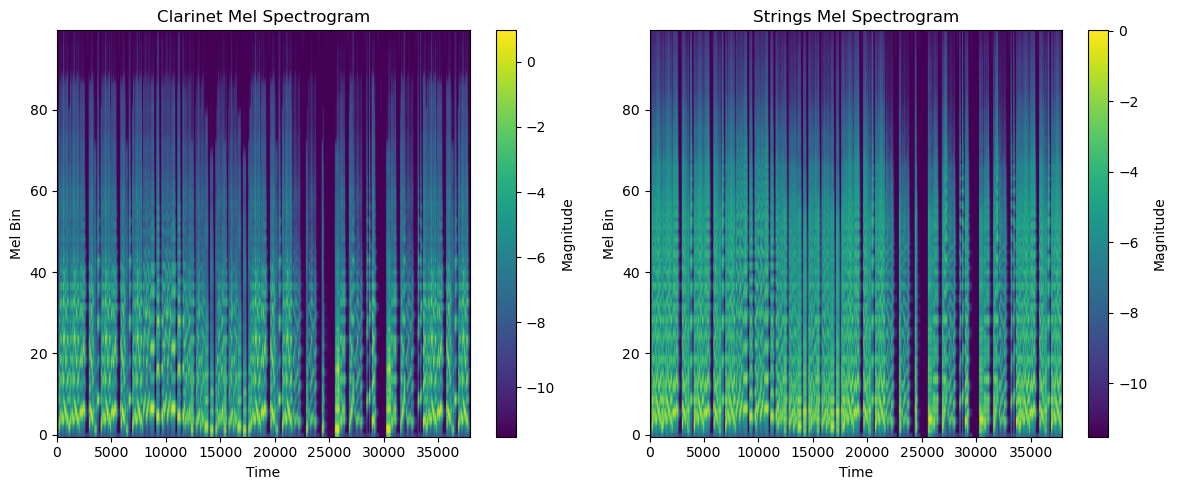

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- paths to your npz files ----
clar_path   = "data/mel_specs/001.clar.npz"
string_path = "data/mel_specs/001.strings.npz"

# ---- load mel specs ----
clar_mel   = np.load(clar_path)["mel"]      # shape (n_mels, T)
string_mel = np.load(string_path)["mel"]    # shape (n_mels, T)

print("Clarinet mel shape:", clar_mel.shape)
print("Strings mel shape:", string_mel.shape)

# ---- plot ----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(clar_mel, aspect='auto', origin='lower')
plt.title("Clarinet Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Bin")
plt.colorbar(label="Magnitude")

plt.subplot(1, 2, 2)
plt.imshow(string_mel, aspect='auto', origin='lower')
plt.title("Strings Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Bin")
plt.colorbar(label="Magnitude")

plt.tight_layout()
plt.show()

In [1]:
import numpy as np

NPZ_PATH = "./data/mel_crops.npz"

data = np.load(NPZ_PATH, allow_pickle=True)

mels = data["mels"]          # shape (N, T, D)
file_ids = data["file_ids"]  # shape (N,)
insts = data["insts"]        # shape (N,)
seg_ids = data["seg_ids"]    # shape (N,)

N, T, D = mels.shape

print("===== mel_crops.npz Summary =====")
print(f"Total rows (crops): {N}")
print(f"Crop shape: (T={T}, D={D})")
print(f"Unique file_ids: {len(set(file_ids))}")
print(f"Unique instruments: {set(insts)}")
print(f"Number of unique segments: {len(set(seg_ids))}")
print("==================================")

===== mel_crops.npz Summary =====
Total rows (crops): 20800
Crop shape: (T=512, D=100)
Unique file_ids: 104
Unique instruments: {'vibes', 'clar', 'strings', 'piano'}
Number of unique segments: 50
